<a href="https://colab.research.google.com/github/bashirrrmk/ML/blob/main/logistic_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic & Linear Regression using Kaggle Dataset

Name: BASHIR AHMAD  
Course: Machine Learning  
Institute: MNNIT ALLAHABAD  

## Objective
The objective of this assignment is to implement and evaluate
Linear Regression and Logistic Regression models using real-world datasets.
The assignment includes data preprocessing, model training, evaluation
using appropriate metrics, and visualization of results.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

## Dataset Description

I have used two datasets in this assignment:

1. Student Performance Dataset:
   - Used for Linear Regression
   - Predicts student exam scores based on hours studied.

2. Titanic Survival Dataset:
   - Used for Logistic Regression
   - Predicts whether a passenger survived the Titanic disaster.

#PART 1
  LINEAR REGRESSION

#Load Dataset


In [4]:
df = pd.read_csv("student_scores.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


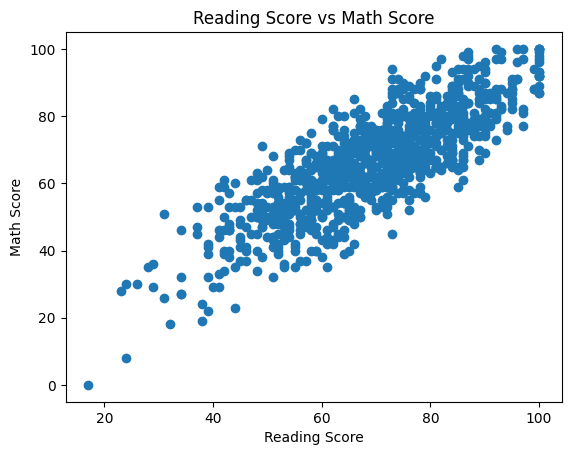

In [5]:
df.info()
df.describe()
df.isnull().sum()

# Visualization (Reading Score vs Math Score)
plt.scatter(df['reading score'], df['math score'])

plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.title("Reading Score vs Math Score")

plt.show()

#Brief Interpretation
The scatter plot shows a strong positive relationship between reading and math scores. This indicates that students with higher reading scores tend to have higher math scores as well.

## Data Preprocessing

The dataset is prepared by selecting the relevant features.
The independent variable (Hours studied) is used to predict
the dependent variable (Exam scores).

In [6]:
X = df[['reading score']]
y = df['math score']

#Train Test Split and Prediction

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)

#Model Evaluation

In [8]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Squared Error: 77.75953982761706
Root Mean Squared Error: 8.818136981676858
R2 Score: 0.6804469009921283


#Visualisation (Prediction vs Actual)

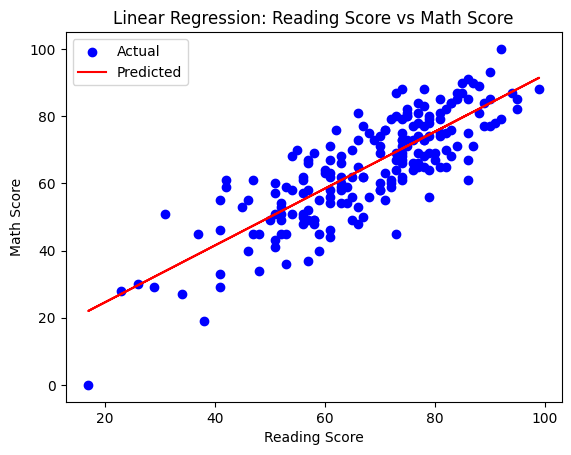

In [9]:
plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.plot(X_test, y_pred, color="red", label="Predicted")

plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.title("Linear Regression: Reading Score vs Math Score")

plt.legend()
plt.show()

#Brief Interpretation
The regression line closely follows the distribution of the data points, indicating that reading score is a good predictor of math score. This suggests a strong linear relationship between reading and math performance.

#PART 2
  LOGISTIC REGRESSION

#Load Dataset

In [10]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#EDA


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


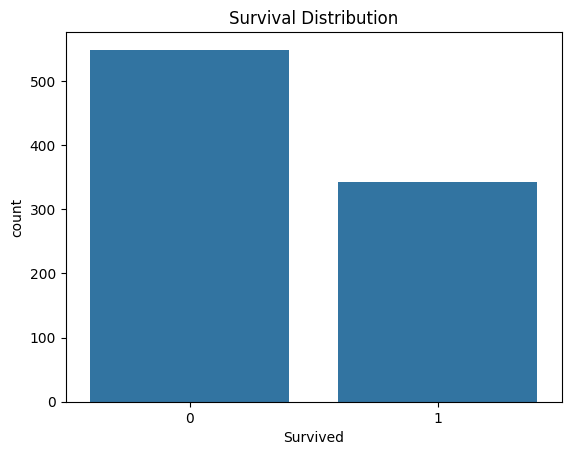

In [11]:
df.info()
df.isnull().sum()

#Survival Distribution
sns.countplot(x='Survived', data=df)
plt.title("Survival Distribution")
plt.show()

#Brief Interpretation
The chart shows that most of the passengers did not survive. This indicates that the survival rate on the Titanic was lower than the death rate

In [12]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


#Data Processing

In [13]:
# Handle missing values
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop unnecessary columns
df.drop(['Name','Ticket','Cabin','PassengerId'], axis=1, inplace=True)

# Encode categorical variables
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])

# One-hot encode Embarked
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

/tmp/ipykernel_226/286861784.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_226/286861784.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [14]:
# Feature and target split
X = df.drop('Survived', axis=1)
y = df['Survived']

#Train Test Split, Feature Scaling and Prediction

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model_log = LogisticRegression()

model_log.fit(X_train, y_train)
y_pred = model_log.predict(X_test)

#Model Evaluation

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8100558659217877
Precision: 0.7857142857142857
Recall: 0.7432432432432432
F1 Score: 0.7638888888888888


#Confusion Matrix

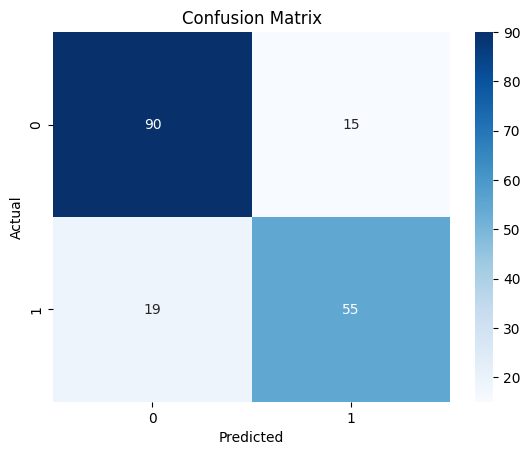

In [17]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Brief Interpretation
The confusion matrix shows that the model correctly predicted most cases, with 90 true negatives and 55 true positives. However, there are some misclassifications, with 15 false positives and 19 false negatives.

#ROC Curve

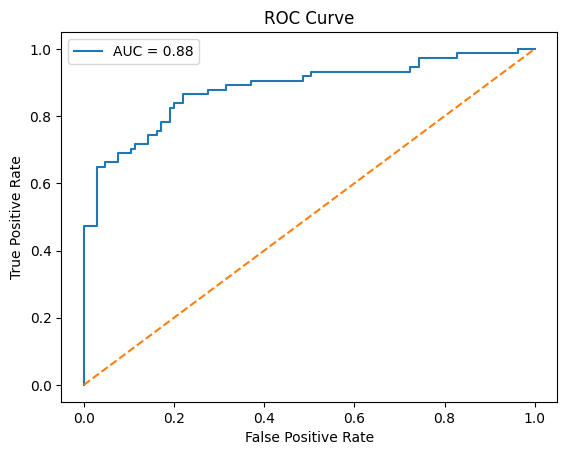

In [18]:
y_prob = model_log.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

#Brief Interpretation
The ROC curve shows that the model performs well in distinguishing between classes, with an AUC of 0.88. This indicates good overall classification performance.

## Conclusion

In this assignment, Linear Regression and Logistic Regression models
were implemented using real-world datasets.

The Linear Regression model was used to predict student scores based
on the number of hours studied. The evaluation metrics such as MSE,
RMSE, and R² indicated that the model captured the relationship
between study time and exam performance effectively.

The Logistic Regression model was applied to the Titanic dataset to
predict passenger survival. Evaluation metrics including accuracy,
precision, recall, and F1-score were used to assess the classification
performance. The confusion matrix and ROC curve further illustrated
the effectiveness of the model.

Overall, the assignment demonstrates how regression and classification
models can be applied to real-world datasets and evaluated using
appropriate metrics.